In [1]:
from google.colab import files
uploaded = files.upload()


Saving val_features.csv to val_features.csv


In [2]:
from google.colab import files
uploaded=files.upload()


Saving train_features.csv to train_features.csv


In [3]:
from google.colab import files
uploaded = files.upload()


Saving test_features.csv to test_features.csv


In [4]:
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Train Shape: (5216, 32)
Test Shape: (624, 32)
Feature Info:        mean       std  min  max    median       p10       p90  skewness  \
0  0.595526  0.268824  0.0  1.0  0.682353  0.039216  0.858824 -1.065181   
1  0.364438  0.231905  0.0  1.0  0.345098  0.031373  0.698039  0.181146   
2  0.347089  0.211556  0.0  1.0  0.376471  0.000000  0.607843 -0.262687   
3  0.562795  0.270892  0.0  1.0  0.666667  0.000000  0.819608 -1.062838   
4  0.548972  0.258394  0.0  1.0  0.627451  0.062745  0.815686 -0.895967   

   kurtosis   entropy  ...     lbp_1     lbp_2     lbp_3     lbp_4     lbp_5  \
0  0.067171  7.192615  ...  0.067978  0.048599  0.093460  0.146637  0.117722   
1 -0.902659  7.473254  ...  0.073624  0.056259  0.093857  0.149963  0.115555   
2 -1.101447  7.042541  ...  0.071533  0.053848  0.086227  0.136810  0.105301   
3 -0.167310  6.940329  ...  0.069153  0.047119  0.086792  0.135147  0.113693   
4 -0.315346  7.263318  ...  0.073730  0.053024  0.087967  0.127136  0.103821   

      lb

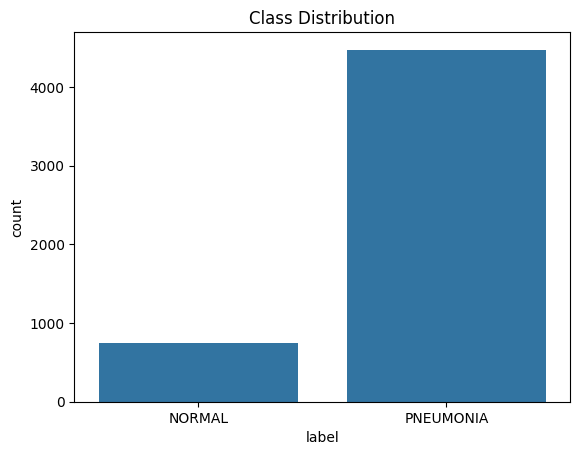

In [9]:
#================================
#2. LOAD DATASETS
# ===============================
train = pd.read_csv("train_features.csv")
test = pd.read_csv("test_features.csv")
var = pd.read_csv("val_features.csv")

# Extract label from 'image' column
train['label'] = train['image'].apply(lambda x: 'NORMAL' if 'NORMAL' in x else 'PNEUMONIA')
test['label'] = test['image'].apply(lambda x: 'NORMAL' if 'NORMAL' in x else 'PNEUMONIA')

# Drop the original 'image' column as it's no longer needed for features
X_train = train.drop('image', axis=1)
X_test = test.drop('image', axis=1)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Feature Info:", var.head())

# ===============================
# 3. BASIC EDA
# ===============================
print(train.head())
print(train.info())
print(train.describe())

# Check class distribution
sns.countplot(x='label', data=train)
plt.title("Class Distribution")
plt.show()

# ===============================
# 4. HANDLE MISSING VALUES
# ===============================
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_test.mean(numeric_only=True))

# ===============================
# 5. SPLIT FEATURES & LABEL
# ===============================
y_train = X_train['label']
X_train = X_train.drop('label', axis=1)

y_test = X_test['label']
X_test = X_test.drop('label', axis=1)


# ===============================
# 6. FEATURE SCALING
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


===== Logistic Regression =====
Accuracy: 0.7035256410256411

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.24      0.05      0.09       165
   PNEUMONIA       0.73      0.94      0.82       459

    accuracy                           0.70       624
   macro avg       0.49      0.50      0.46       624
weighted avg       0.60      0.70      0.63       624



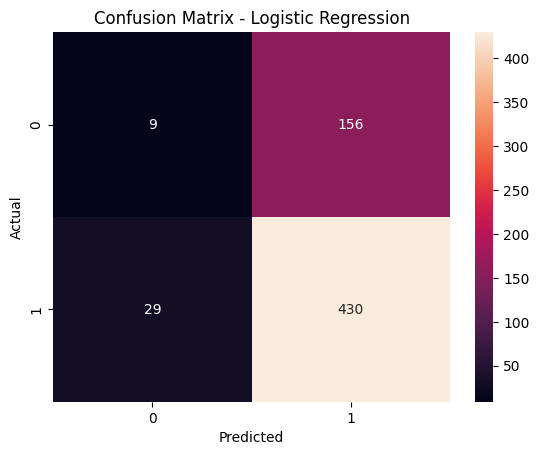


===== Random Forest =====
Accuracy: 0.7435897435897436

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.56      0.13      0.22       165
   PNEUMONIA       0.76      0.96      0.85       459

    accuracy                           0.74       624
   macro avg       0.66      0.55      0.53       624
weighted avg       0.70      0.74      0.68       624



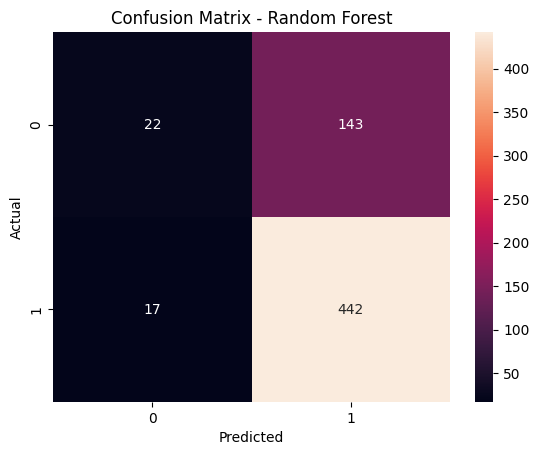


===== SVM =====
Accuracy: 0.7099358974358975

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.23      0.04      0.07       165
   PNEUMONIA       0.73      0.95      0.83       459

    accuracy                           0.71       624
   macro avg       0.48      0.50      0.45       624
weighted avg       0.60      0.71      0.63       624



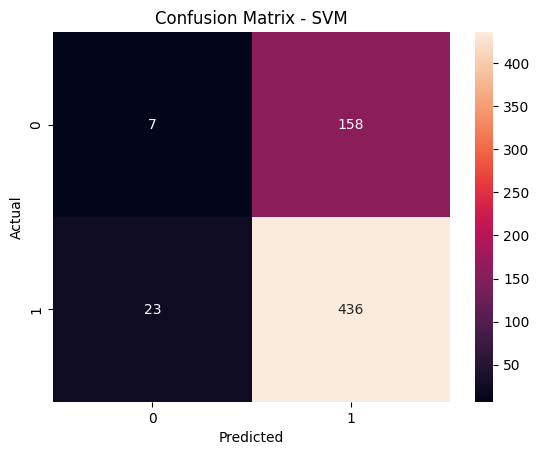

In [10]:
# ===============================
# 7. FEATURE SELECTION
# ===============================
selector = SelectKBest(score_func=f_classif, k=20)  # select top 20 features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# ===============================
# 8. DIMENSIONALITY REDUCTION (PCA)
# ===============================
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

# ===============================
# 9. MODELS
# ===============================
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

# ===============================
# 10. TRAIN & EVALUATE
# ===============================
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()